In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df_train = pd.read_csv("../data/processed/train_data.csv")
df_test = pd.read_csv("../data/processed/test_data.csv")

In [7]:
def generateDescribe(train,test,col):
    df_temp = train[col].describe().reset_index()
    df_temp.columns = ["metrica",f"train_{col}"]
    df_temp[f"test_{col}"] = test[col].describe().values
    df_temp = df_temp.set_index("metrica")
    return df_temp



In [8]:
print(f"Dados de treino : Linhas {df_train.shape[0]} | Colunas {df_train.shape[1]}" )
print(f"Dados de teste  : Linhas {df_test.shape[0]} | Colunas {df_test.shape[1]}" )

Dados de treino : Linhas 150000 | Colunas 11
Dados de teste  : Linhas 101503 | Colunas 10


# Valores nulos

In [5]:
df_train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
df_test.isnull().sum()

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20103
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2626
dtype: int64

In [7]:
df_train.isnull().mean()

SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           0.198207
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      0.026160
dtype: float64

In [8]:
df_test.isnull().mean()

RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           0.198053
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      0.025871
dtype: float64

# Distribuição

## Idade

In [9]:
generateDescribe(df_train,df_test,"age")

,train_age,test_age
metrica,,
count,150000.000000,101503.000000
mean,52.295207,52.405436
std,14.771866,14.779756
min,0.000000,21.000000
25%,41.000000,41.000000
50%,52.000000,52.000000
75%,63.000000,63.000000
max,109.000000,104.000000


<Axes: title={'center': 'Distribuição de Idade Teste'}, xlabel='age', ylabel='Count'>

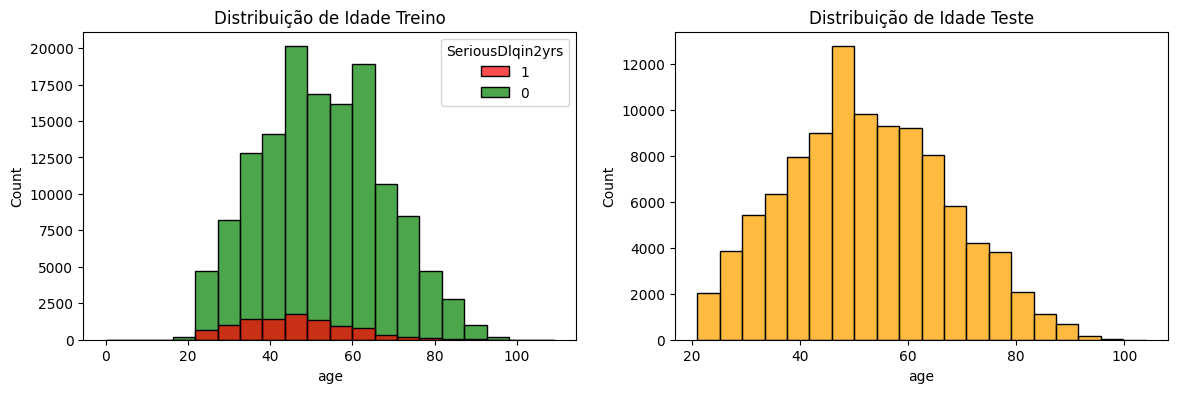

In [10]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição de Idade Treino")
sns.histplot(df_train,x="age",bins=20,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[1].set_title("Distribuição de Idade Teste")
sns.histplot(df_test,x="age",bins=20,ax=axis[1],color="orange")


<Axes: xlabel='SeriousDlqin2yrs', ylabel='age'>

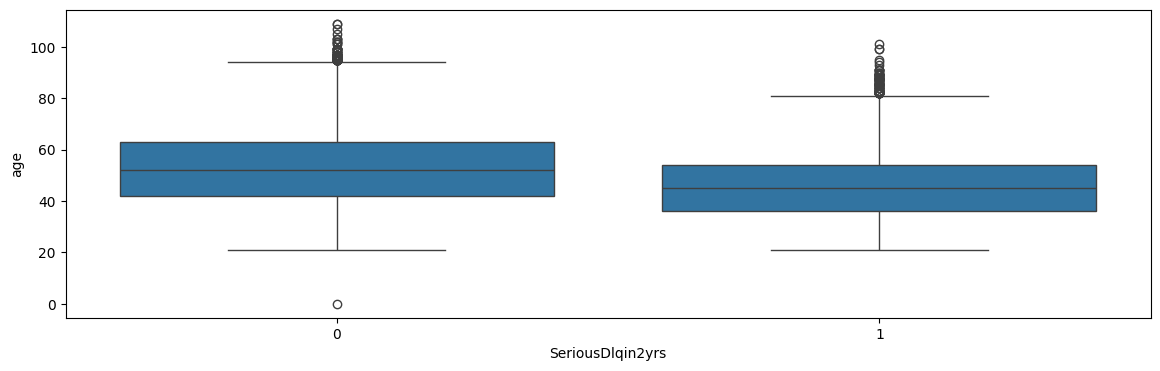

In [11]:
bins = range(0,df_train["age"].max(),20)
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="age",x="SeriousDlqin2yrs")

# NumberOfTime30-59DaysPastDueNotWorse

In [12]:
generateDescribe(df_train,df_test,"NumberOfTime30-59DaysPastDueNotWorse")

,train_NumberOfTime30-59DaysPastDueNotWorse,test_NumberOfTime30-59DaysPastDueNotWorse
metrica,,
count,150000.000000,101503.000000
mean,0.421033,0.453770
std,4.192781,4.538487
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


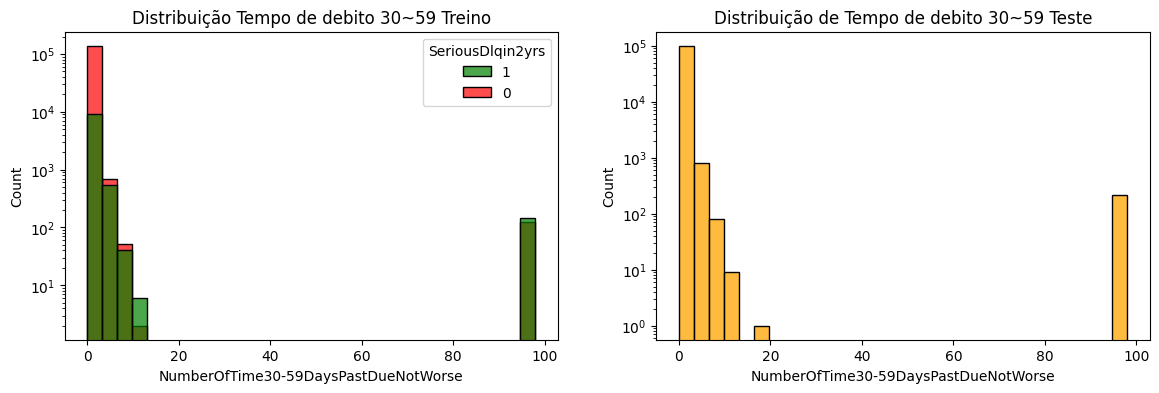

In [38]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Tempo de debito 30~59 Treino")
sns.histplot(df_train,x="NumberOfTime30-59DaysPastDueNotWorse",bins=30,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={1: "green", 0: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[1].set_title("Distribuição de Tempo de debito 30~59 Teste")
sns.histplot(df_test,x="NumberOfTime30-59DaysPastDueNotWorse",bins=30,ax=axis[1],color="orange")
axis[1].set_yscale("log")

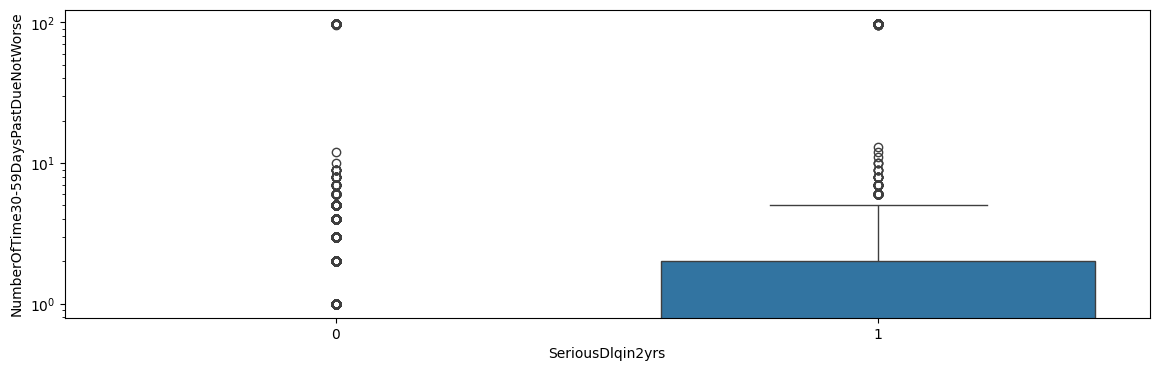

In [14]:
bins = range(0,df_train["age"].max(),20)
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfTime30-59DaysPastDueNotWorse",x="SeriousDlqin2yrs")
axis.set_yscale("log")

# DebtRatio

In [15]:
generateDescribe(df_train,df_test,"DebtRatio")

,train_DebtRatio,test_DebtRatio
metrica,,
count,150000.000000,101503.000000
mean,353.005076,344.475020
std,2037.818523,1632.595231
min,0.000000,0.000000
25%,0.175074,0.173423
50%,0.366508,0.364260
75%,0.868254,0.851619
max,329664.000000,268326.000000


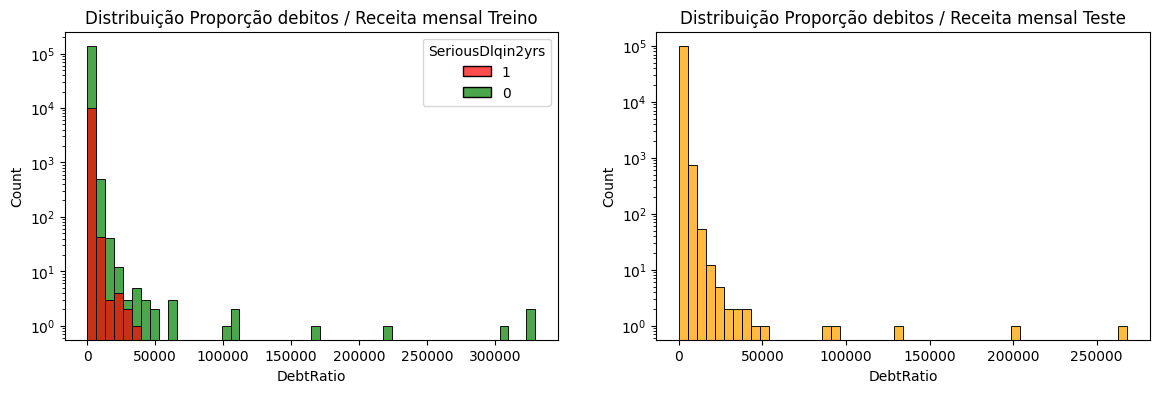

In [16]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Proporção debitos / Receita mensal Treino")
sns.histplot(df_train,x="DebtRatio",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[1].set_title("Distribuição Proporção debitos / Receita mensal Teste")
sns.histplot(df_test,x="DebtRatio",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")

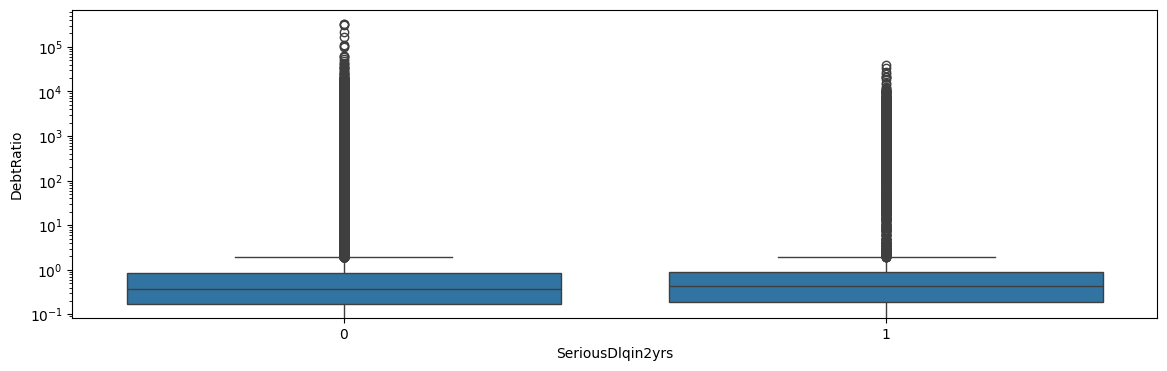

In [17]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="DebtRatio",x="SeriousDlqin2yrs")
axis.set_yscale("log")

## Receita mensal

In [18]:
generateDescribe(df_train,df_test,"MonthlyIncome")

,train_MonthlyIncome,test_MonthlyIncome
metrica,,
count,1.202690e+05,8.140000e+04
mean,6.670221e+03,6.855036e+03
std,1.438467e+04,3.650860e+04
min,0.000000e+00,0.000000e+00
25%,3.400000e+03,3.408000e+03
50%,5.400000e+03,5.400000e+03
75%,8.249000e+03,8.200000e+03
max,3.008750e+06,7.727000e+06


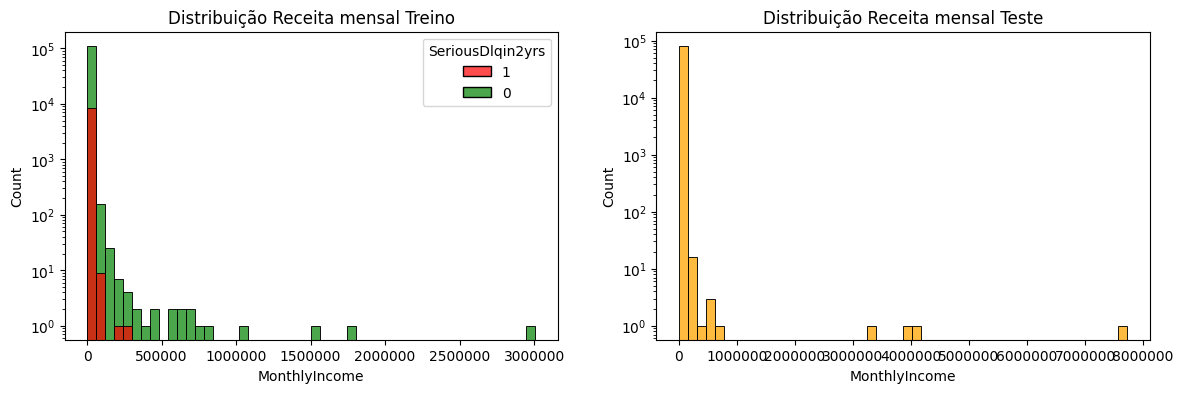

In [19]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Receita mensal Treino")
sns.histplot(df_train,x="MonthlyIncome",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Receita mensal Teste")
sns.histplot(df_test,x="MonthlyIncome",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

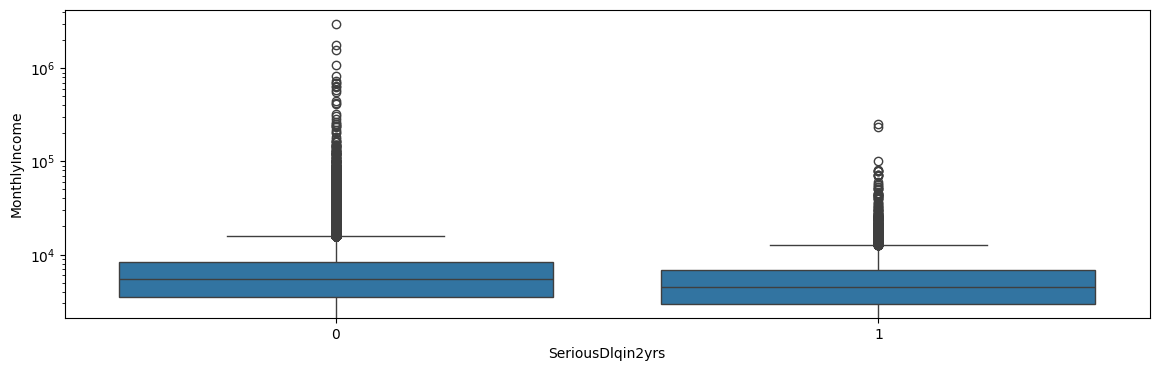

In [20]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="MonthlyIncome",x="SeriousDlqin2yrs")
axis.set_yscale("log")


## Emprestimos Ativos

In [21]:
generateDescribe(df_train,df_test,"NumberOfOpenCreditLinesAndLoans")

,train_NumberOfOpenCreditLinesAndLoans,test_NumberOfOpenCreditLinesAndLoans
metrica,,
count,150000.000000,101503.000000
mean,8.452760,8.453514
std,5.145951,5.144100
min,0.000000,0.000000
25%,5.000000,5.000000
50%,8.000000,8.000000
75%,11.000000,11.000000
max,58.000000,85.000000


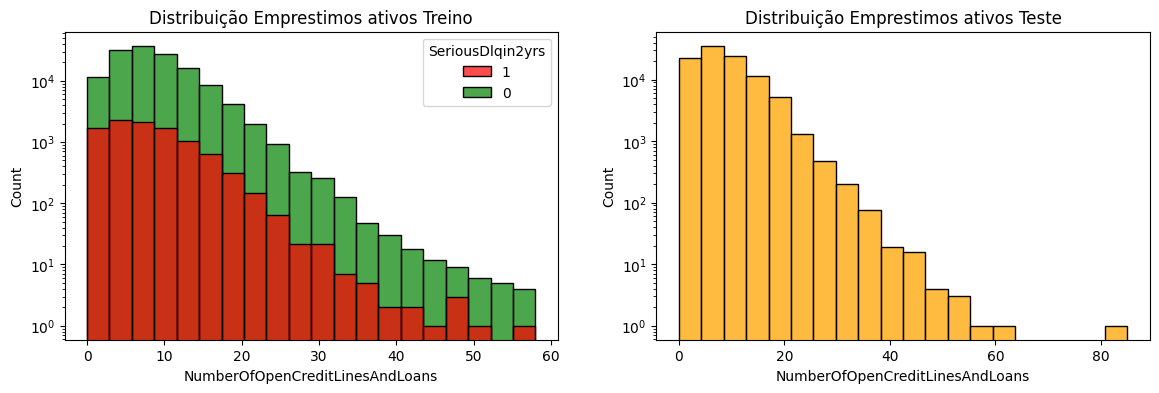

In [22]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Emprestimos ativos Treino")
sns.histplot(df_train,x="NumberOfOpenCreditLinesAndLoans",bins=20,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Emprestimos ativos Teste")
sns.histplot(df_test,x="NumberOfOpenCreditLinesAndLoans",bins=20,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

## Numero de atrasos mais de 90 dias

In [23]:
generateDescribe(df_train,df_test,"NumberOfTimes90DaysLate")

,train_NumberOfTimes90DaysLate,test_NumberOfTimes90DaysLate
metrica,,
count,150000.000000,101503.000000
mean,0.265973,0.296691
std,4.169304,4.515859
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


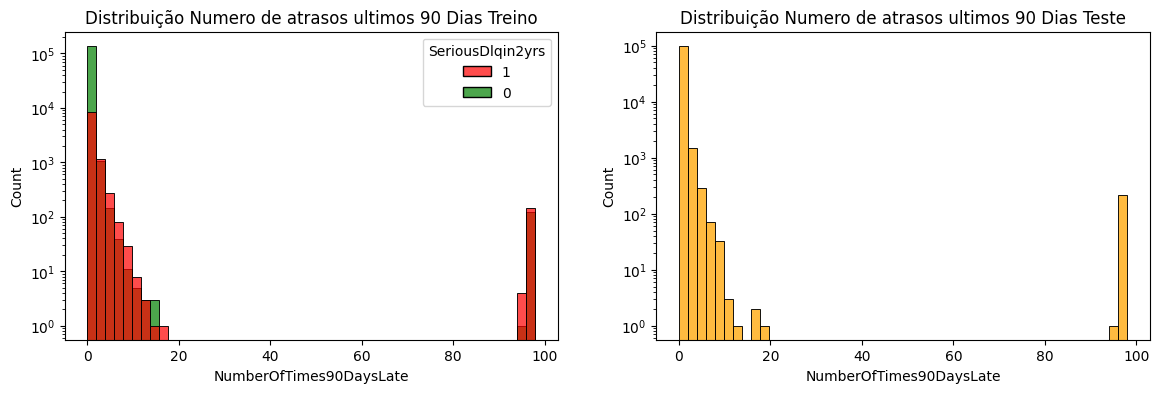

In [24]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Numero de atrasos ultimos 90 Dias Treino")
sns.histplot(df_train,x="NumberOfTimes90DaysLate",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Numero de atrasos ultimos 90 Dias Teste")
sns.histplot(df_test,x="NumberOfTimes90DaysLate",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

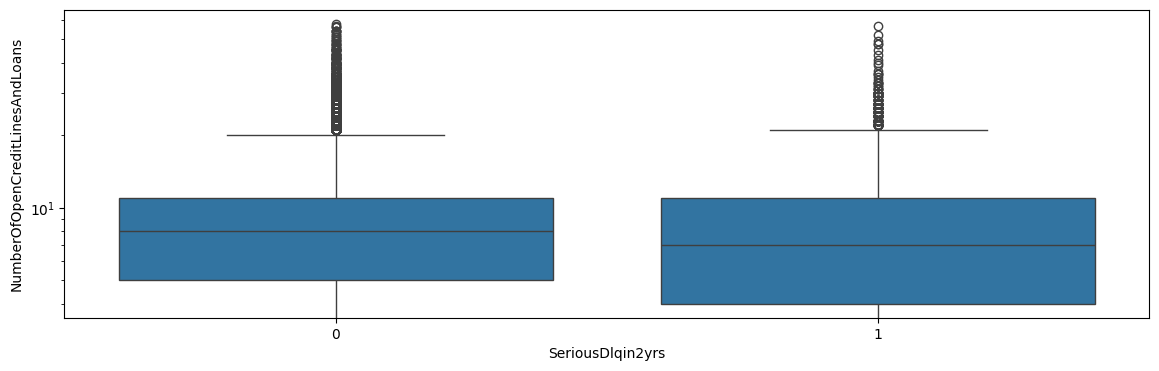

In [25]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfOpenCreditLinesAndLoans",x="SeriousDlqin2yrs")
axis.set_yscale("log")

## Hipotecas e emprestimos imobiliarios

In [26]:
generateDescribe(df_train,df_test,"NumberRealEstateLoansOrLines")


,train_NumberRealEstateLoansOrLines,test_NumberRealEstateLoansOrLines
metrica,,
count,150000.000000,101503.000000
mean,1.018240,1.013074
std,1.129771,1.110253
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,54.000000,37.000000


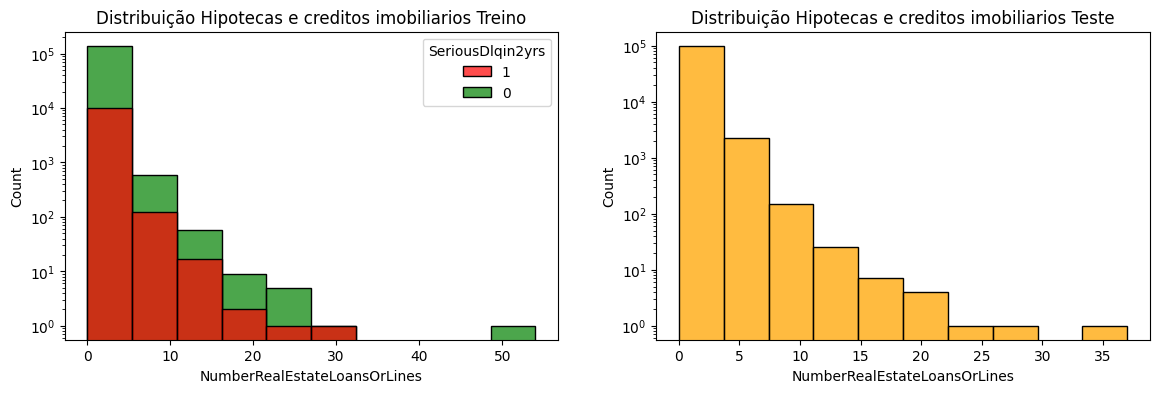

In [27]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Hipotecas e creditos imobiliarios Treino")
sns.histplot(df_train,x="NumberRealEstateLoansOrLines",bins=10,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Hipotecas e creditos imobiliarios Teste")
sns.histplot(df_test,x="NumberRealEstateLoansOrLines",bins=10,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

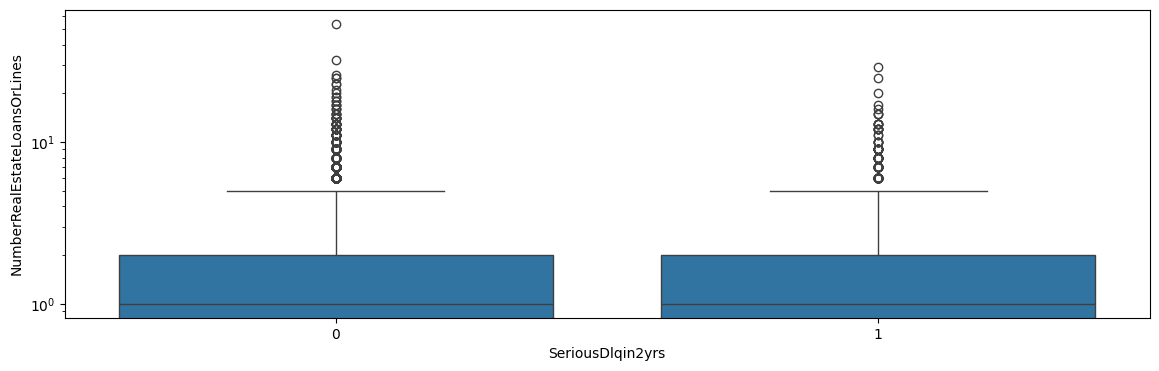

In [28]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberRealEstateLoansOrLines",x="SeriousDlqin2yrs")
axis.set_yscale("log")

## Mais de 90 dias em atraso

In [29]:
generateDescribe(df_train,df_test,"NumberOfTime60-89DaysPastDueNotWorse")

,train_NumberOfTime60-89DaysPastDueNotWorse,test_NumberOfTime60-89DaysPastDueNotWorse
metrica,,
count,150000.000000,101503.000000
mean,0.240387,0.270317
std,4.155179,4.503578
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


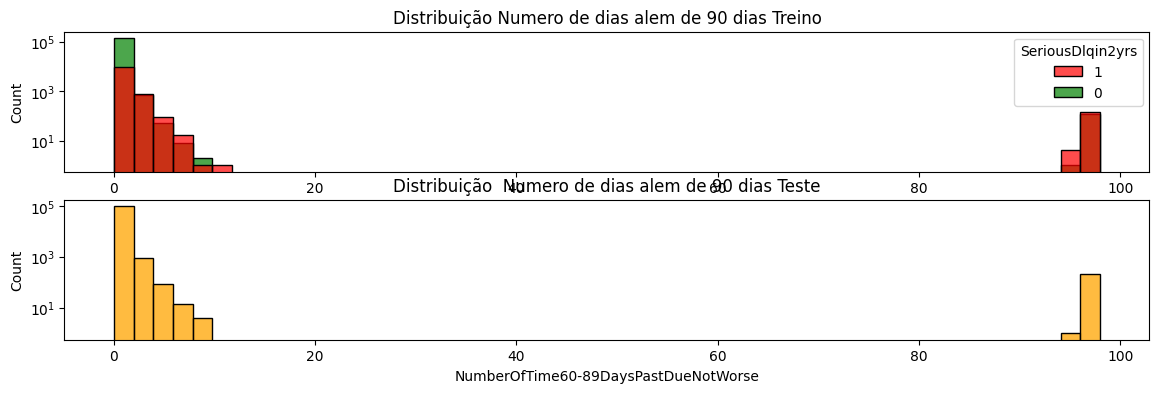

In [30]:
fig, axis = plt.subplots(2,1,figsize=(14, 4))
axis[0].set_title("Distribuição Numero de dias alem de 90 dias Treino")
sns.histplot(df_train,x="NumberOfTime60-89DaysPastDueNotWorse",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição  Numero de dias alem de 90 dias Teste")
sns.histplot(df_test,x="NumberOfTime60-89DaysPastDueNotWorse",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

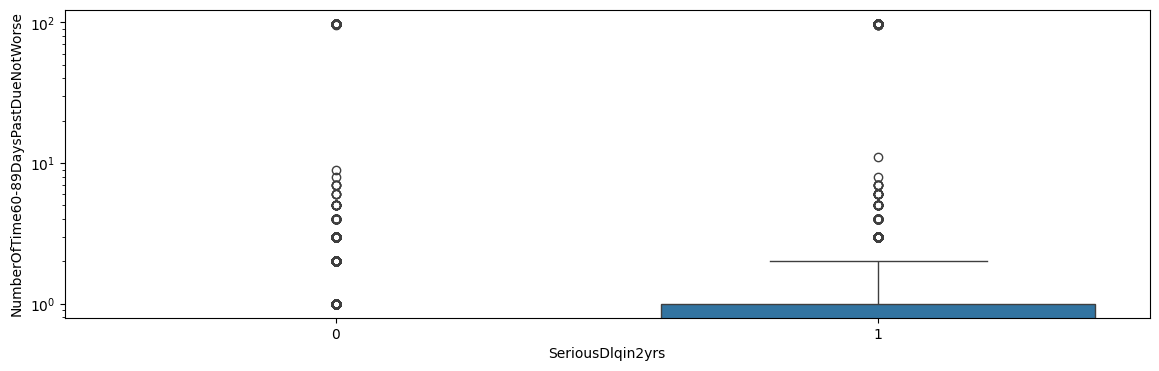

In [31]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfTime60-89DaysPastDueNotWorse",x="SeriousDlqin2yrs")
axis.set_yscale("log")

## Numero de dependentes

In [32]:
generateDescribe(df_train,df_test,"NumberOfDependents")

,train_NumberOfDependents,test_NumberOfDependents
metrica,,
count,146076.000000,98877.000000
mean,0.757222,0.769046
std,1.115086,1.136778
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,20.000000,43.000000


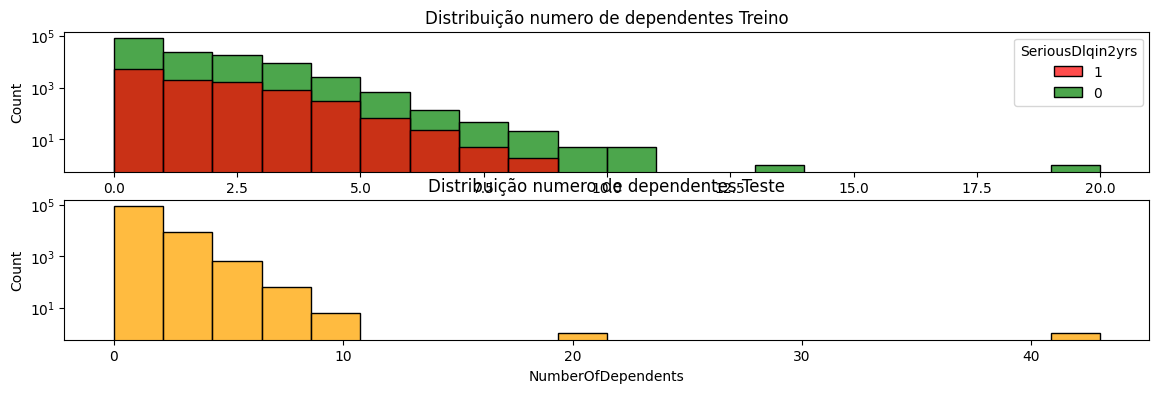

In [33]:
fig, axis = plt.subplots(2,1,figsize=(14, 4))
axis[0].set_title("Distribuição numero de dependentes Treino")
sns.histplot(df_train,x="NumberOfDependents",bins=int(df_train["NumberOfDependents"].max()),hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')

axis[1].set_title("Distribuição numero de dependentes Teste")
sns.histplot(df_test,x="NumberOfDependents",bins=20,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfDependents'>

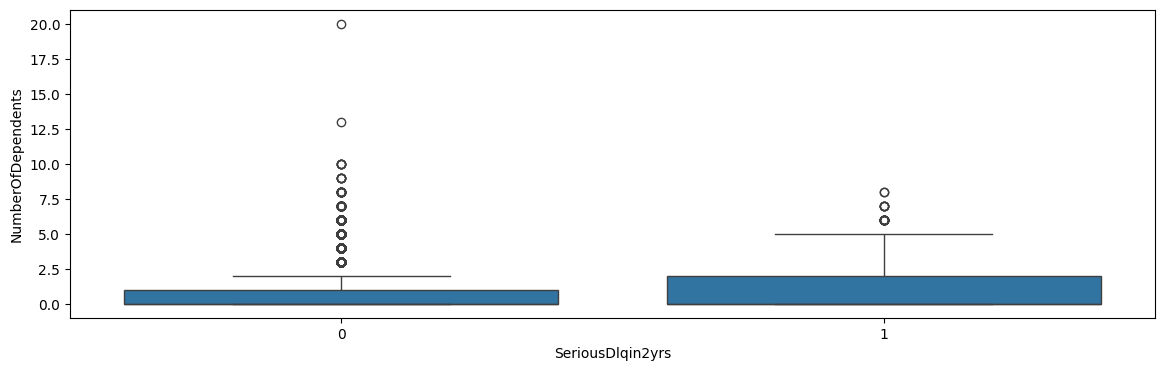

In [34]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfDependents",x="SeriousDlqin2yrs")

# Matriz de correlação 

<Axes: >

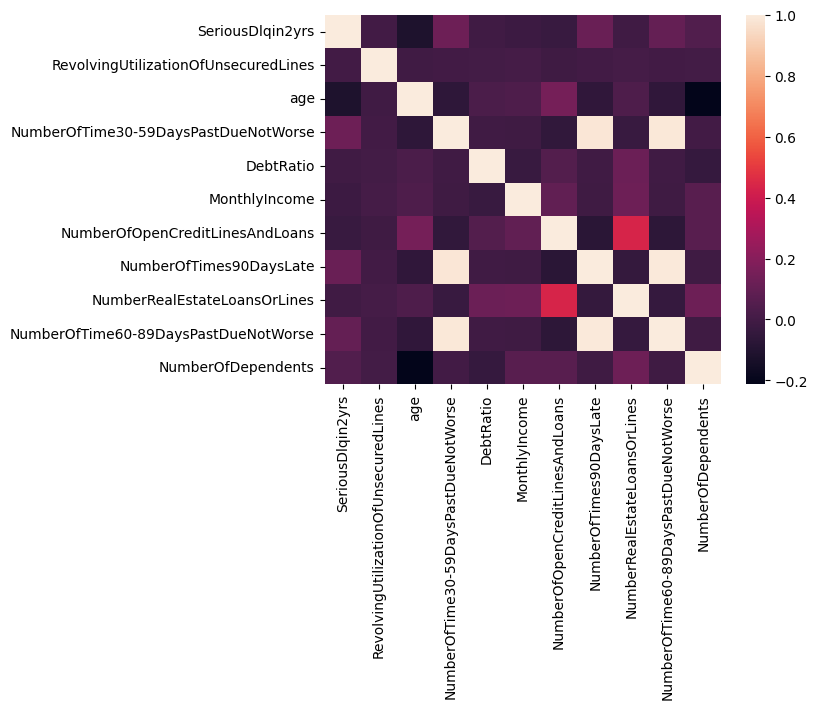

In [35]:
sns.heatmap(df_train.corr())

ModuleNotFoundError: No module named 'ydata_profiling'